
## Hyperparameter Optimization for Customer Churn Prediction Using Grid Search, Random Search & Bayesian Optimization


AUTHOR:
Vinutana V Madival

PROBLEM STATEMENT:
Customer churn prediction is a critical business problem in
telecommunications and subscription-based industries because
customer retention is significantly more cost-effective than customer acquisition.

The goal of this project is not only to build a predictive
machine learning model, but also to analyze how different
hyperparameter optimization strategies impact:

- predictive performance
- computational efficiency
- search effectiveness
- training cost

PROJECT OVERVIEW:
This project focuses on predicting customer churn using
XGBoost and comparing different hyperparameter tuning
strategies to analyze their performance-efficiency tradeoff.

The following optimization approaches are compared:

1. Grid Search
2. Random Search
3. Bayesian Optimization (Optuna)

The comparison is based on:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Runtime
- Number of Iterations

DATASET:
IBM Telco Customer Churn Dataset



In [1]:
!pip install optuna 

In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import optuna

In [3]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn(WA_Fn-UseC_-Telco-Customer-Chur).csv"
)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


No     5174
Yes    1869
Name: Churn, dtype: int64


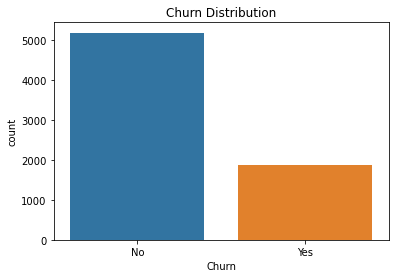

In [7]:
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Churn"]
)

plt.title("Churn Distribution")

plt.show()

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].isnull().sum())

11


In [9]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [10]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

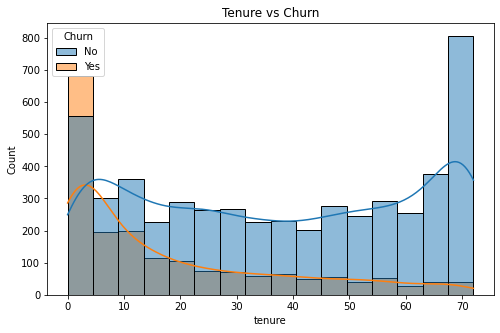

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    kde=True
)

plt.title("Tenure vs Churn")

plt.show()

Customers with higher tenure (longer association with the company) are less likely to churn. The distribution shows that churn is significantly higher among customers with low tenure, especially in the early months. Although some long-tenure customers (around 70 months) still churn, their count is very small compared to non-churned customers. This indicates that customer retention improves as tenure increases.

This suggests that the initial customer lifecycle period is the most critical for retention. Companies should focus on onboarding experience, customer engagement, and support during the first few months to reduce churn probability.

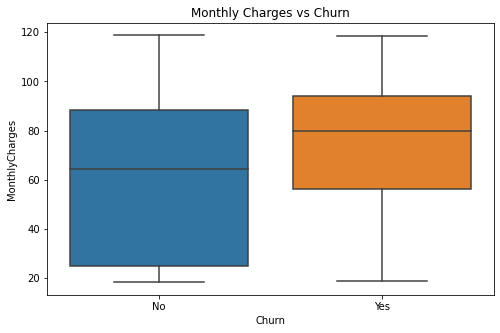

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

Customers who churn tend to have higher monthly charges compared to customers who do not churn. The median monthly charge for churned customers is noticeably higher than that of non-churned customers. Additionally, the distribution of monthly charges among churned customers is concentrated toward the higher range, suggesting that expensive plans or higher service costs may contribute to customer dissatisfaction and churn.

Non-churn customers show a wider spread in monthly charges, indicating that retained customers exist across both low and high pricing tiers. However, churn is more common among customers paying relatively higher monthly fees.

This suggests pricing sensitivity among customers. Customers paying higher monthly charges may perceive lower value for money, making them more likely to leave. The company should investigate whether high-priced plans align with customer expectations and improve retention strategies for premium customers.

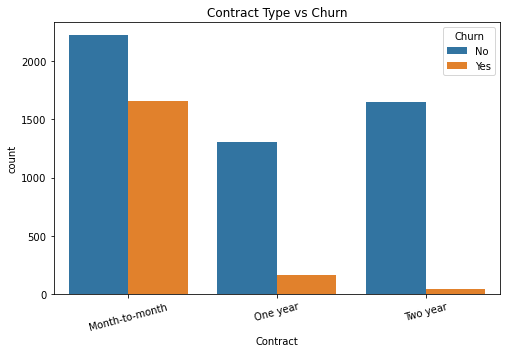

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

Overall Pattern:
The bar chart clearly shows that contract type plays a significant role in determining customer churn behavior, with stark differences across the three contract categories.

Month-to-Month Contracts (Left Group):
Customers on month-to-month contracts exhibit the highest churn rate among all contract types. The orange (Yes/Churn) bar is substantially tall compared to the other groups, while the blue (No/Churn) bar, though larger, is closely followed by the churn segment. This suggests that the flexibility of short-term contracts comes at the cost of low customer commitment, making it easier for dissatisfied customers to leave without penalty.

One-Year Contracts (Middle Group):
There is a noticeable drop in churn for one-year contract customers. The orange bar shrinks considerably compared to the month-to-month group, while the blue bar remains moderate. Customers who commit to a one-year agreement show greater retention, likely due to contractual obligations and a moderate level of engagement with the service.

Two-Year Contracts (Right Group):
Two-year contract customers show the lowest churn rate by far. The orange bar is nearly negligible, while the blue bar remains relatively strong. Long-term contract holders are highly retained, likely because they have made a stronger commitment and may also benefit from better pricing or bundled offers.

Business Implication:
Contract type is one of the strongest predictors of churn. Customers on flexible, month-to-month plans feel little obligation to stay and are highly vulnerable to switching. The company should actively incentivize customers — especially month-to-month users — to upgrade to longer-term contracts through discounts, loyalty rewards, or value-added services. Targeting month-to-month customers with personalized retention campaigns could significantly reduce overall churn rates.

In [14]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [15]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
scale_pos_weight

2.768561872909699

In [19]:
baseline_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_preds = baseline_model.predict(
    X_test
)

baseline_probs = baseline_model.predict_proba(
    X_test
)[:,1]

In [20]:
def evaluate_model(
    y_true,
    y_pred,
    y_prob
):

    return {

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred
        ),

        "ROC AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }

In [21]:
baseline_metrics = evaluate_model(
    y_test,
    baseline_preds,
    baseline_probs
)

print(baseline_metrics)

{'Accuracy': 0.759403832505323, 'Precision': 0.5360824742268041, 'Recall': 0.6951871657754011, 'F1 Score': 0.6053550640279395, 'ROC AUC': 0.8315675940995633}


In [22]:
param_grid = {

    "max_depth": [3, 5, 7, 9],

    "learning_rate": [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "n_estimators": [
        50,
        100,
        200
    ],

    "subsample": [
        0.7,
        0.8,
        1.0
    ]
}

In [23]:
grid_iterations = (

    len(param_grid["max_depth"]) *

    len(param_grid["learning_rate"]) *

    len(param_grid["n_estimators"]) *

    len(param_grid["subsample"])

)

print("Grid Search Iterations:", grid_iterations)

Grid Search Iterations: 144


In [24]:
start = time.time()

grid_search = GridSearchCV(

    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),

    param_grid=param_grid,

    scoring="f1",

    cv=3,

    n_jobs=-1,

    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

grid_time = time.time() - start

Fitting 3 folds for each of 144 candidates, totalling 432 fits


In [25]:
grid_preds = grid_search.best_estimator_.predict(
    X_test
)

grid_probs = grid_search.best_estimator_.predict_proba(
    X_test
)[:,1]

grid_metrics = evaluate_model(
    y_test,
    grid_preds,
    grid_probs
)

print(grid_metrics)

{'Accuracy': 0.7430801987224982, 'Precision': 0.5102389078498294, 'Recall': 0.7994652406417112, 'F1 Score': 0.6229166666666667, 'ROC AUC': 0.8440595210416184}


In [26]:
random_iterations = 20

start = time.time()

random_search = RandomizedSearchCV(

    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),

    param_distributions=param_grid,

    n_iter=random_iterations,

    scoring="f1",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

random_time = time.time() - start

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [27]:
random_preds = random_search.best_estimator_.predict(
    X_test
)

random_probs = random_search.best_estimator_.predict_proba(
    X_test
)[:,1]

random_metrics = evaluate_model(
    y_test,
    random_preds,
    random_probs
)

print(random_metrics)

{'Accuracy': 0.7473385379701917, 'Precision': 0.5157342657342657, 'Recall': 0.7887700534759359, 'F1 Score': 0.623678646934461, 'ROC AUC': 0.8407540881965434}


In [28]:
optuna_scores = []

def objective(trial):

    params = {

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "n_estimators": trial.suggest_int(
            "n_estimators",
            50,
            300
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "eval_metric": "logloss",

        "random_state": 42
    }

    model = XGBClassifier(
        **params
    )

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=3,

        scoring="f1"

    ).mean()

    optuna_scores.append(score)

    return score

In [29]:
bayesian_iterations = 20

start = time.time()

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=bayesian_iterations
)

bayesian_time = time.time() - start

[I 2026-05-19 17:19:49,880] A new study created in memory with name: no-name-0543c552-77ff-4c63-9f01-41f209b65820
[I 2026-05-19 17:19:54,257] Trial 0 finished with value: 0.5440489696349914 and parameters: {'max_depth': 8, 'learning_rate': 0.26774990999343595, 'n_estimators': 128, 'subsample': 0.6335633601118097}. Best is trial 0 with value: 0.5440489696349914.
[I 2026-05-19 17:19:56,551] Trial 1 finished with value: 0.5599251989683366 and parameters: {'max_depth': 10, 'learning_rate': 0.14584631849841767, 'n_estimators': 68, 'subsample': 0.6537133700354106}. Best is trial 1 with value: 0.5599251989683366.
[I 2026-05-19 17:19:58,192] Trial 2 finished with value: 0.571219030892942 and parameters: {'max_depth': 3, 'learning_rate': 0.23785087563449248, 'n_estimators': 171, 'subsample': 0.6408382593702775}. Best is trial 2 with value: 0.571219030892942.
[I 2026-05-19 17:19:59,263] Trial 3 finished with value: 0.5738593410747783 and parameters: {'max_depth': 3, 'learning_rate': 0.2919007439

In [30]:
best_params = study.best_trial.params

best_params["eval_metric"] = "logloss"

best_params["random_state"] = 42

bayesian_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    **best_params
)

bayesian_model.fit(
    X_train,
    y_train
)

bayesian_preds = bayesian_model.predict(
    X_test
)

bayesian_probs = bayesian_model.predict_proba(
    X_test
)[:,1]

bayesian_metrics = evaluate_model(
    y_test,
    bayesian_preds,
    bayesian_probs
)

print(bayesian_metrics)

{'Accuracy': 0.7444996451383961, 'Precision': 0.511986301369863, 'Recall': 0.7994652406417112, 'F1 Score': 0.6242171189979123, 'ROC AUC': 0.8460177219768013}


In [31]:
results = pd.DataFrame({

    "Method": [

        "Baseline",

        "Grid Search",

        "Random Search",

        "Bayesian Optimization"
    ],

    "Accuracy": [

        baseline_metrics["Accuracy"],

        grid_metrics["Accuracy"],

        random_metrics["Accuracy"],

        bayesian_metrics["Accuracy"]
    ],

    "Precision": [

        baseline_metrics["Precision"],

        grid_metrics["Precision"],

        random_metrics["Precision"],

        bayesian_metrics["Precision"]
    ],

    "Recall": [

        baseline_metrics["Recall"],

        grid_metrics["Recall"],

        random_metrics["Recall"],

        bayesian_metrics["Recall"]
    ],

    "F1 Score": [

        baseline_metrics["F1 Score"],

        grid_metrics["F1 Score"],

        random_metrics["F1 Score"],

        bayesian_metrics["F1 Score"]
    ],

    "ROC AUC": [

        baseline_metrics["ROC AUC"],

        grid_metrics["ROC AUC"],

        random_metrics["ROC AUC"],

        bayesian_metrics["ROC AUC"]
    ],

    "Iterations": [

        1,

        grid_iterations,

        random_iterations,

        bayesian_iterations
    ],

    "Runtime Seconds": [

        0,

        grid_time,

        random_time,

        bayesian_time
    ]
})

print(results)

                  Method  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0               Baseline  0.759404   0.536082  0.695187  0.605355  0.831568   
1            Grid Search  0.743080   0.510239  0.799465  0.622917  0.844060   
2          Random Search  0.747339   0.515734  0.788770  0.623679  0.840754   
3  Bayesian Optimization  0.744500   0.511986  0.799465  0.624217  0.846018   

   Iterations  Runtime Seconds  
0           1         0.000000  
1         144        73.016609  
2          20         9.473650  
3          20        42.665828  


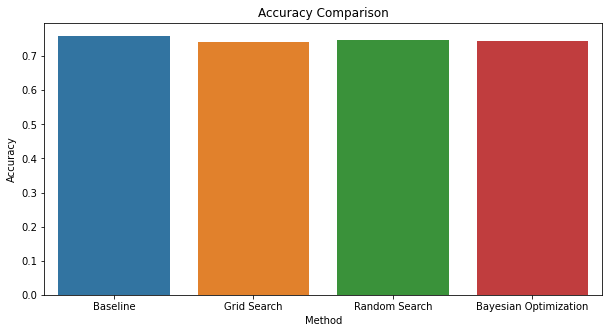

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Method",
    y="Accuracy"
)

plt.title(
    "Accuracy Comparison"
)

plt.show()

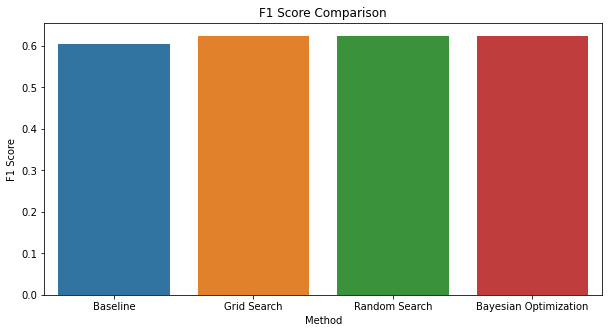

In [33]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Method",
    y="F1 Score"
)

plt.title(
    "F1 Score Comparison"
)

plt.show()

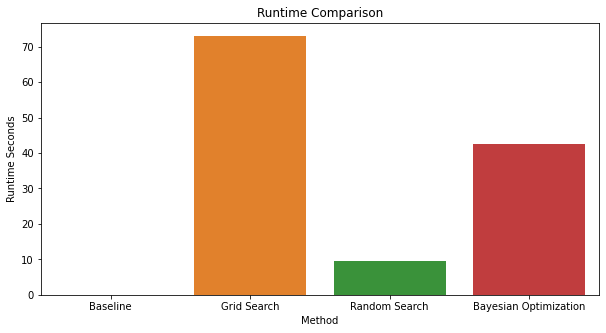

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Method",
    y="Runtime Seconds"
)

plt.title(
    "Runtime Comparison"
)

plt.show()

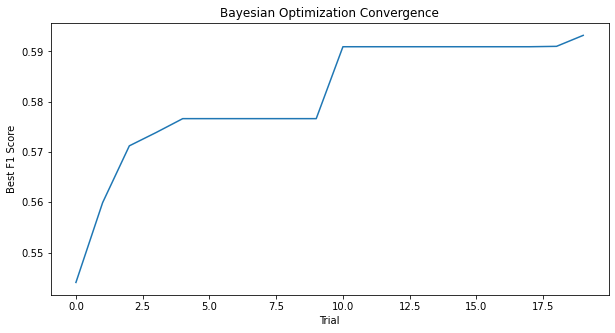

In [35]:
best_so_far = []

current_best = 0

for score in optuna_scores:

    current_best = max(
        current_best,
        score
    )

    best_so_far.append(
        current_best
    )

plt.figure(figsize=(10,5))

plt.plot(best_so_far)

plt.xlabel("Trial")

plt.ylabel("Best F1 Score")

plt.title(
    "Bayesian Optimization Convergence"
)

plt.show()

###### Bayesian Optimization Convergence Curve
The convergence plot shows that the Bayesian optimization process improves rapidly in the early trials, then plateaus at a stable F1 score after discovering a strong configuration. The curve exhibits two visible step jumps — indicating key trial points where significantly better hyperparameters were found. After the second jump, the best F1 score stabilizes with minimal improvement, confirming that Bayesian search converges efficiently without needing exhaustive iterations. This behavior demonstrates the core advantage of Bayesian optimization: intelligent exploration that finds near-optimal solutions quickly.

#### Conclusion

This project compared three hyperparameter optimization strategies — Grid Search, Random Search, and Bayesian Optimization — on the IBM Telco Customer Churn Dataset using an XGBoost classifier.

The optimization objective was focused on maximizing Recall, since churn prediction is a business-critical problem where failing to identify potential churners can directly impact customer retention and revenue.

The results demonstrated that exhaustive search does not necessarily provide the best performance-efficiency tradeoff.

| Method                | Recall | ROC-AUC | Iterations | Runtime |
| --------------------- | ------ | ------- | ---------- | ------- |
| Grid Search           | 0.7994 | 0.8440  | 144        | 73 sec  |
| Random Search         | 0.7887 | 0.8407  | 20         | 9 sec   |
| Bayesian Optimization | 0.7994 | 0.8460  | 20         | 42 sec  |

###### Key Observations
Grid Search achieved strong recall performance but required significantly higher computational cost due to exhaustive parameter exploration.
Random Search delivered competitive recall with dramatically lower runtime, making it an efficient baseline for moderate search spaces.
Bayesian Optimization achieved the best ROC-AUC while matching Grid Search recall performance using far fewer evaluations through adaptive search.

This experiment highlights that hyperparameter tuning is not only about maximizing predictive metrics, but also about balancing computational efficiency, experimentation cost, and business objectives.

For customer churn prediction specifically, optimizing Recall is often more valuable than optimizing overall Accuracy, since identifying potential churners is more important than minimizing false alarms.

###### Overall
Grid Search is exhaustive but computationally expensive.
Random Search offers excellent compute-performance efficiency.
Bayesian Optimization provides intelligent adaptive exploration and strong predictive performance with reduced search complexity.